In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/ai4i2020.csv')
print(df.shape)
df.info()
df.head()

(10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [8]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
for col in failure_types:
    print(f"{col}: {df[col].sum()} kasus")

TWF: 46 kasus
HDF: 115 kasus
PWF: 95 kasus
OSF: 98 kasus
RNF: 19 kasus


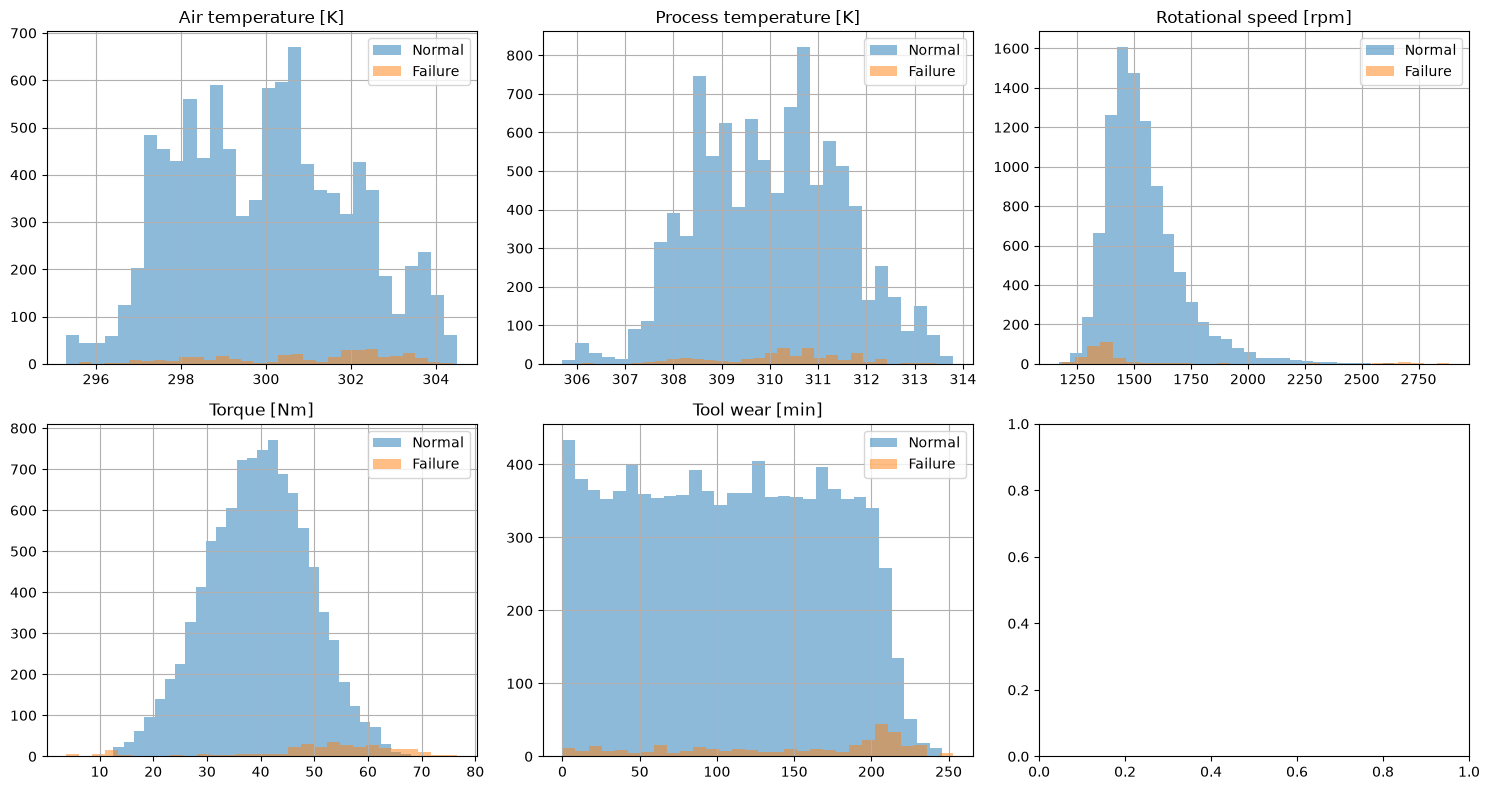

                 Air temperature [K]  Process temperature [K]  \
Machine failure                                                 
0                             299.97                   310.00   
1                             300.89                   310.29   

                 Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Machine failure                                                        
0                               1540.26        39.63           106.69  
1                               1496.49        50.17           143.78  


In [ ]:
import matplotlib.pyplot as plt

sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 
               'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(sensor_cols):
    ax = axes[i // 3, i % 3]
    df[df['Machine failure'] == 0][col].hist(ax=ax, alpha=0.5, label='Normal', bins=30)
    df[df['Machine failure'] == 1][col].hist(ax=ax, alpha=0.5, label='Failure', bins=30)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

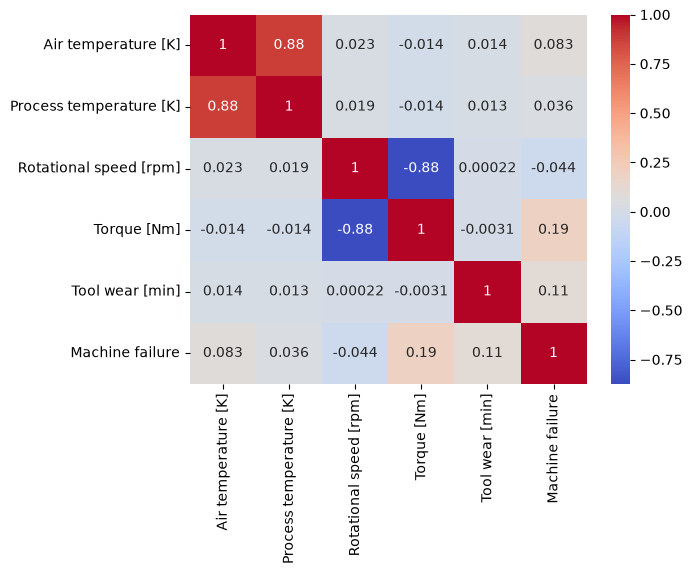

Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


In [ ]:
import seaborn as sns

corr = df[sensor_cols + ['Machine failure']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()